# LeNet-5


## 简介
LeNet-5 是由杨立昆教授在 1998 年提出的，是最早、最经典的卷积神经网络之一。最初被设计用于解决手写数字识别问题（著名的 MNIST 数据集），在银行业的支票识别系统中得到了广泛应用。

## 架构
卷积编码器 + 全连接层密集块
![LeNet](./images/LeNet-5.png)


## 实现


In [1]:
import torch
from torch import nn
import torchinfo
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
class Reshape(nn.Module):
    """将输入张量重塑为指定形状"""
    def forward(self, x):
        # (batch_size, 输入通道, 高, 宽)
        return x.view(-1, 1, 28, 28)

net = nn.Sequential(
    Reshape(), # (B, 1, 28, 28)
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(), # (B, 6, 28, 28)
    nn.AvgPool2d(kernel_size=2, stride=2), # (B, 6, 14, 14)
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(), # (B, 16, 10, 10)
    nn.AvgPool2d(kernel_size=2, stride=2), # (B, 16, 5, 5)
    nn.Flatten(), # (B, 16 * 5 * 5)
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(), # (B, 120)
    nn.Linear(120, 84), nn.Sigmoid(), # (B, 84)
    nn.Linear(84, 10) # (B, 10)
)

检查模型


In [3]:
torchinfo.summary(net, input_size=(1, 28, 28), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Sequential                               [1, 28, 28]               [1, 10]                   --
├─Reshape: 1-1                           [1, 28, 28]               [1, 1, 28, 28]            --
├─Conv2d: 1-2                            [1, 1, 28, 28]            [1, 6, 28, 28]            156
├─Sigmoid: 1-3                           [1, 6, 28, 28]            [1, 6, 28, 28]            --
├─AvgPool2d: 1-4                         [1, 6, 28, 28]            [1, 6, 14, 14]            --
├─Conv2d: 1-5                            [1, 6, 14, 14]            [1, 16, 10, 10]           2,416
├─Sigmoid: 1-6                           [1, 16, 10, 10]           [1, 16, 10, 10]           --
├─AvgPool2d: 1-7                         [1, 16, 10, 10]           [1, 16, 5, 5]             --
├─Flatten: 1-8                           [1, 16, 5, 5]             [1, 400]                  --
├─Linear: 1-9                  

用 fashion MNIST 训练


In [4]:
batch_size = 256
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size)


训练 LeNet-5

loss 1.062, train acc 0.596, test acc 0.604
106508.1 examples/sec on cuda:0


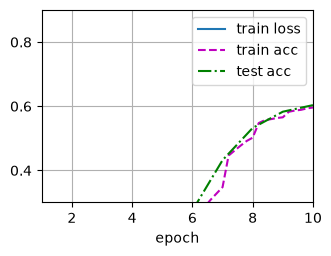

In [5]:
lr, num_epochs = 0.1, 10
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, device=util.try_gpu())

In [6]:
torch.save(net.state_dict(), "./models/LeNet.pth")